In [1]:
from comet.multiverse import Multiverse

forking_paths = {
    "X1": [0, 1],
    "X2": [0, 1],
    "X3": [0, 1],
    "X4": [0, 1],
    "ANTE": [0, 1],
    "MEDI": [0, 1],
    "COLL": [0, 1],
    "CONF": [0, 1],
}

def analysis_template():
    import comet
    import statsmodels.formula.api as smf

    data = comet.utils.load_example("cantone")
    
    # Build composite predictor
    data["pred"] = 0.0
    if {{X1}}:
        data["pred"] += data["BM1"]
    if {{X2}}:
        data["pred"] += data["BM2"]
    if {{X3}}:
        data["pred"] += data["BM3"]
    if {{X4}}:
        data["pred"] += data["BM4"]

    # Build covariates
    cov = ""
    if {{ANTE}}:
        cov += " + genotype"
    if {{MEDI}}:
        cov += " + pain"
    if {{COLL}}:
        cov += " + fatigue"
    if {{CONF}}:
        cov += " + age"

    # Regression model
    formula = "depression ~ pred" + cov
    fit_res = smf.ols(formula=formula, data=data).fit()

    beta_raw = float(fit_res.params["pred"])
    sd_y = float(data["depression"].std())
    sd_x = float(data["pred"].std())
    beta_std = beta_raw * (sd_x / sd_y)

    out = {
        "formula": formula,
        "beta": float(beta_std),
        "beta_raw": float(beta_raw),
        "p_value": float(fit_res.pvalues["pred"]),
        "bic": float(fit_res.bic),
    }

    comet.utils.save_universe_results(out)

config = {
    "remove": [
        [{"X1": 0}, {"X2": 0}, {"X3": 0}, {"X4": 0}],
    ]
}

mverse = Multiverse(name="example_mv_integration")
mverse.create(analysis_template, forking_paths, config)
mverse.summary()
#mverse.run(parallel=16)

Removed 16 out of 256 universes:


,Universe,Decision 1,Value 1,Decision 2,Value 2,Decision 3,Value 3,Decision 4,Value 4,Decision 5,Value 5,Decision 6,Value 6,Decision 7,Value 7,Decision 8,Value 8
0,Universe_1,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,0,CONF,0
1,Universe_2,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,0,CONF,1
2,Universe_3,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,1,CONF,0
3,Universe_4,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,1,CONF,1
4,Universe_5,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,1,COLL,0,CONF,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Universe_236,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,0,COLL,1,CONF,1
236,Universe_237,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,0,CONF,0
237,Universe_238,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,0,CONF,1
238,Universe_239,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,1,CONF,0


We can visualise the multiverse results:

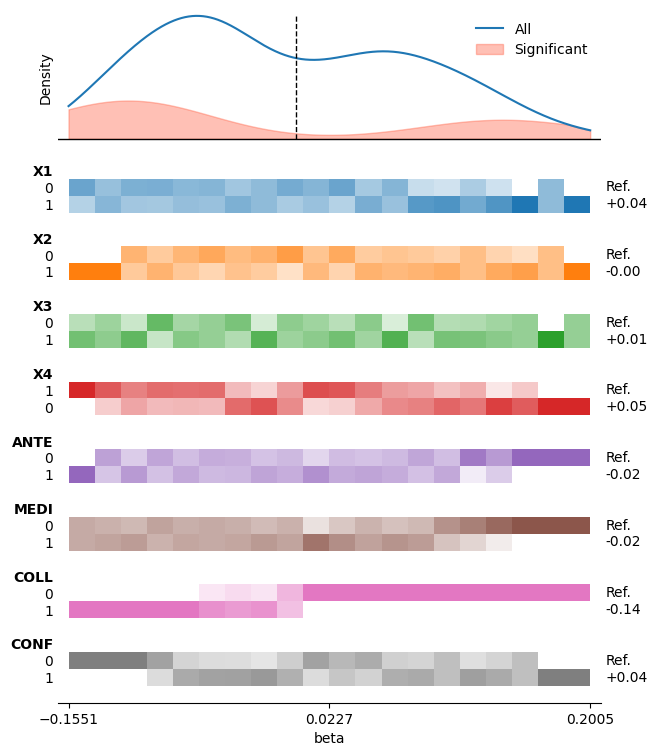

In [2]:
mverse.multiverse_plot(measure="beta", n_bins=20, sig_col="p_value", baseline=0, figsize=(7,9))

And perform integration with the methods proposed in:

> Cantone, G. G., & Tomaselli, V. (2025). Characterisation and calibration of multiversal methods.  
> Advances in Data Analysis and Classification, 19(4), 989-1021. https://doi.org/10.1007/s11634-024-00610-9

Briefly, the integration methods estimate weights for each universe, and then aggregate via weighted mean or weighted median. Available methods are:

`uniform`
- All universes are weighted equally (the estimate is just the plain mean/median across universes).

`BMA` (Bayesian model averaging)
- Requires a bic column in the results (has to be provided as an argument). Better-fitting specifications receive exponentially more weight.

`MYH` (Muñoz–Young–Holsteen influence score)
- A meta-regression of the measure on the analytic decisions gives each universe an influence score (how strongly the decisions it uses move the estimate). Universes built from the most influential decisions get more weight.

`MYHN` (inverse MYH)
- Opposite of MYH. The least influential specifications get more weight, penalising complexity. This is a more conservative, robustness-oriented scheme.

`MLI` (Maximum Local Influence)
- Each universe is compared with its nearest neighbours (specifications differing by a single decision). Universes whose estimate barely changes when one decision is flipped are weighted more, down-weighting results that hinge on a single arbitrary choice.


As an example, we now simply get the mean beta over all universes (uniform weighting):

In [14]:
estimate, weights = mverse.integrate(measure="beta", method="uniform", type="mean")
print(f"Mean beta: {estimate:.4f}")

Mean beta: -0.0066


We can also use the `compare_integration` and `plot_integration` convenience functions to get a summary for all integration methods:

In [8]:
table, weights = mverse.compare_integration(measure="beta", bic_column="bic")
table

,Scheme,median,mean,gini_w,highest_w,highest_w_universe
0,Uniform,-0.0210,-0.0066,0.000,NaN,NaN
1,BMA,-0.0677,-0.0624,0.949,-0.0854,universe_72
2,MYH,-0.0513,-0.0284,0.166,-0.0746,universe_240
3,MYHN,0.0558,0.0522,0.449,0.1120,universe_49
4,MLI,-0.0328,-0.0144,0.243,-0.0763,universe_4


The columns are, for each weighting `Scheme`:

- `median` / `mean`: the integrated estimate — the weighted median / weighted mean of `beta`.
- `gini_w`: how concentrated the weights are (0 = all equal, → 1 = dominated by a few universes).
- `highest_w`: `beta` of the single highest-weighted universe (`NaN` if the top weight is not unique).
- `highest_w_universe`: which universe that is (`NaN` for `uniform`, where every universe is tied).

If `true_value` is passed, additional `err_*` columns give the absolute error of each estimate against it.

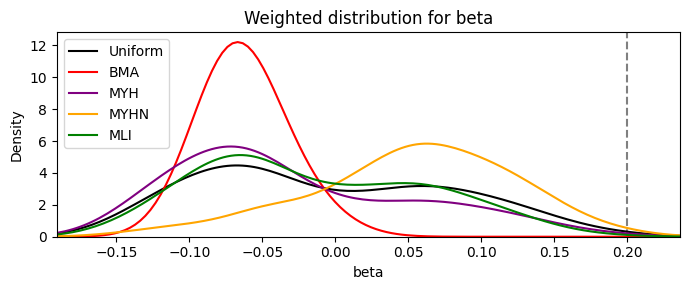

In [9]:
mverse.plot_integration(measure="beta", weights=weights, true_value=0.2)